# How well do jobs and skills pay for Data Analyst

Methology
 1. Evaluate median salary for top 6 data jobs 
 2. Find median salary per skills for Data Scienties
 3. Visualize for highest paying skills and most demanding skills

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# loading Data 
from datasets import  load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
# cleaning data 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/Users/badal/anaconda3/envs/advance_python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg'])
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785563,Data Scientist,Data Scientist I/II (Model Risk Management & M...,"Pensacola, FL",via Navy Federal Credit Union - Talentify,Full-time,False,"Florida, United States",2023-01-11 06:22:10,False,False,United States,year,136400.0,NaN,Navy Federal Credit Union,"[r, python, matplotlib, ggplot2, spark, word, ...","{'analyst_tools': ['word', 'power bi', 'tablea..."
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"[go, python, r, sql, oracle, windows, alteryx,...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
785641,Data Engineer,Data Engineer,"New York, NY",via Dice,Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,NaN,"Engage Partners, Inc.",None,None
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,NaN,84.51°,"[python, azure, snowflake, spark]","{'cloud': ['azure', 'snowflake'], 'libraries':..."


In [10]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [20]:
df_US_Top6 = df_US[df_US['job_title_short'].isin(job_titles)]
job_order = df_US_Top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index
job_order
# df_US_Top6['job_title_short'].value_counts()

Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='object', name='job_title_short')

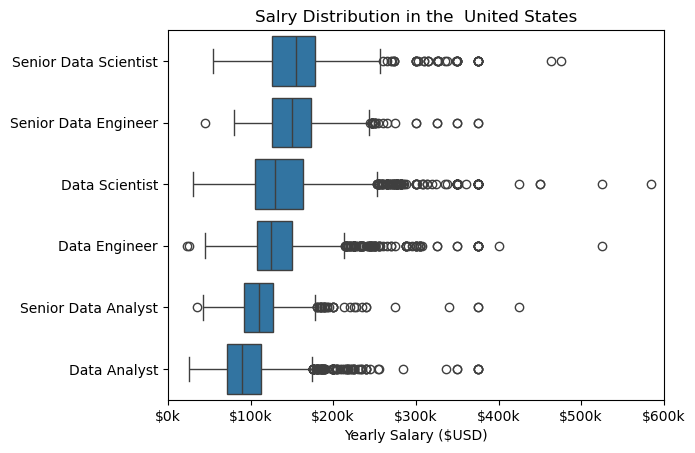

In [21]:
sns.boxplot(data = df_US_Top6 ,x = 'salary_year_avg',y= 'job_title_short',fill=True,order=job_order)
plt.title('Salry Distribution in the  United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.xlim(0,600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'${int(x/1000)}k'))
plt.show()

# Investigate Median Salary VS Skill For Data Scientist

In [22]:
df_DS_US = df[(df['job_title_short']=='Data Scientist') & (df['job_country'] == "United States")].copy()
df_DS_US = df_DS_US.dropna(subset='salary_year_avg')


In [23]:
df_DS_US =df_DS_US.explode('job_skills')
df_DS_US[['salary_year_avg','job_skills']].head(5)

In [27]:
df_DS_top_pay = df_DS_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'median',ascending = False)
df_DS_top_pay = df_DS_top_pay.head(10)

In [30]:
df_DS_top_skills = df_DS_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'count',ascending = False)
df_DS_top_skills = df_DS_top_skills.head(10).sort_values(by = 'median',ascending = False)

In [33]:
df_DS_top_pay

,count,median
job_skills,,
asana,5,259000.00000
airtable,6,224250.00000
watson,10,213500.00000
unreal,4,211500.00000
ruby on rails,4,195500.00000
redhat,1,189500.00000
notion,9,187500.00000
slack,11,180000.00000
hugging face,15,179000.00000


In [31]:
df_DS_top_skills


,count,median
job_skills,,
tensorflow,474,149646.0
spark,718,135959.5
sql,2463,134500.0
aws,768,134000.0
python,3358,131867.0
r,2053,126000.0
tableau,989,125000.0
hadoop,468,125000.0
excel,490,124290.0


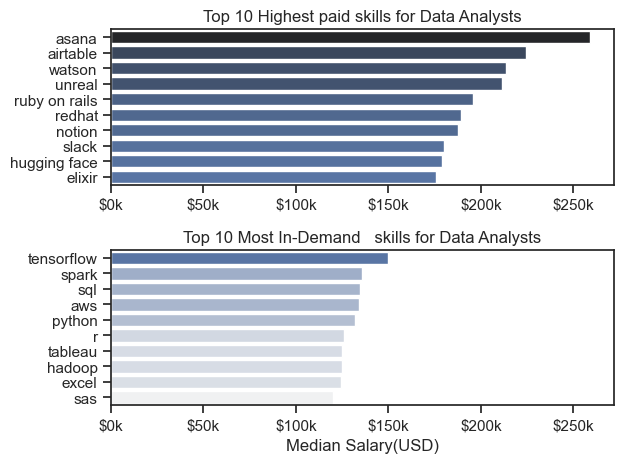

In [34]:
fig ,ax = plt.subplots(2,1)
sns.set_theme(style='ticks')
# df_DA_top_pay.iloc[::-1].plot(kind='barh',y='median',ax=ax[0],legend=False)
sns.barplot(data =df_DS_top_pay,y=df_DS_top_pay.index,x='median',ax=ax[0],hue='median',palette='dark:b_r')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f"${int(x/1000)}k"))
ax[0].set_title("Top 10 Highest paid skills for Data Analysts")
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].legend().remove()
# df_DA_skillls.iloc[::-1].plot(kind='barh',y='median',ax=ax[1],legend=False)
sns.barplot(data = df_DS_top_skills,y=df_DS_top_skills.index,x='median',ax=ax[1],hue='median',palette='light:b')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title("Top 10 Most In-Demand   skills for Data Analysts")
ax[1].set_xlabel('Median Salary(USD)')
ax[1].set_ylabel('')
ax[1].legend().remove()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f"${int(x/1000)}k"))
plt.tight_layout()
plt.show()